<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Probability_of_Awakening_Auditory_Arousal_Threshold_Model_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

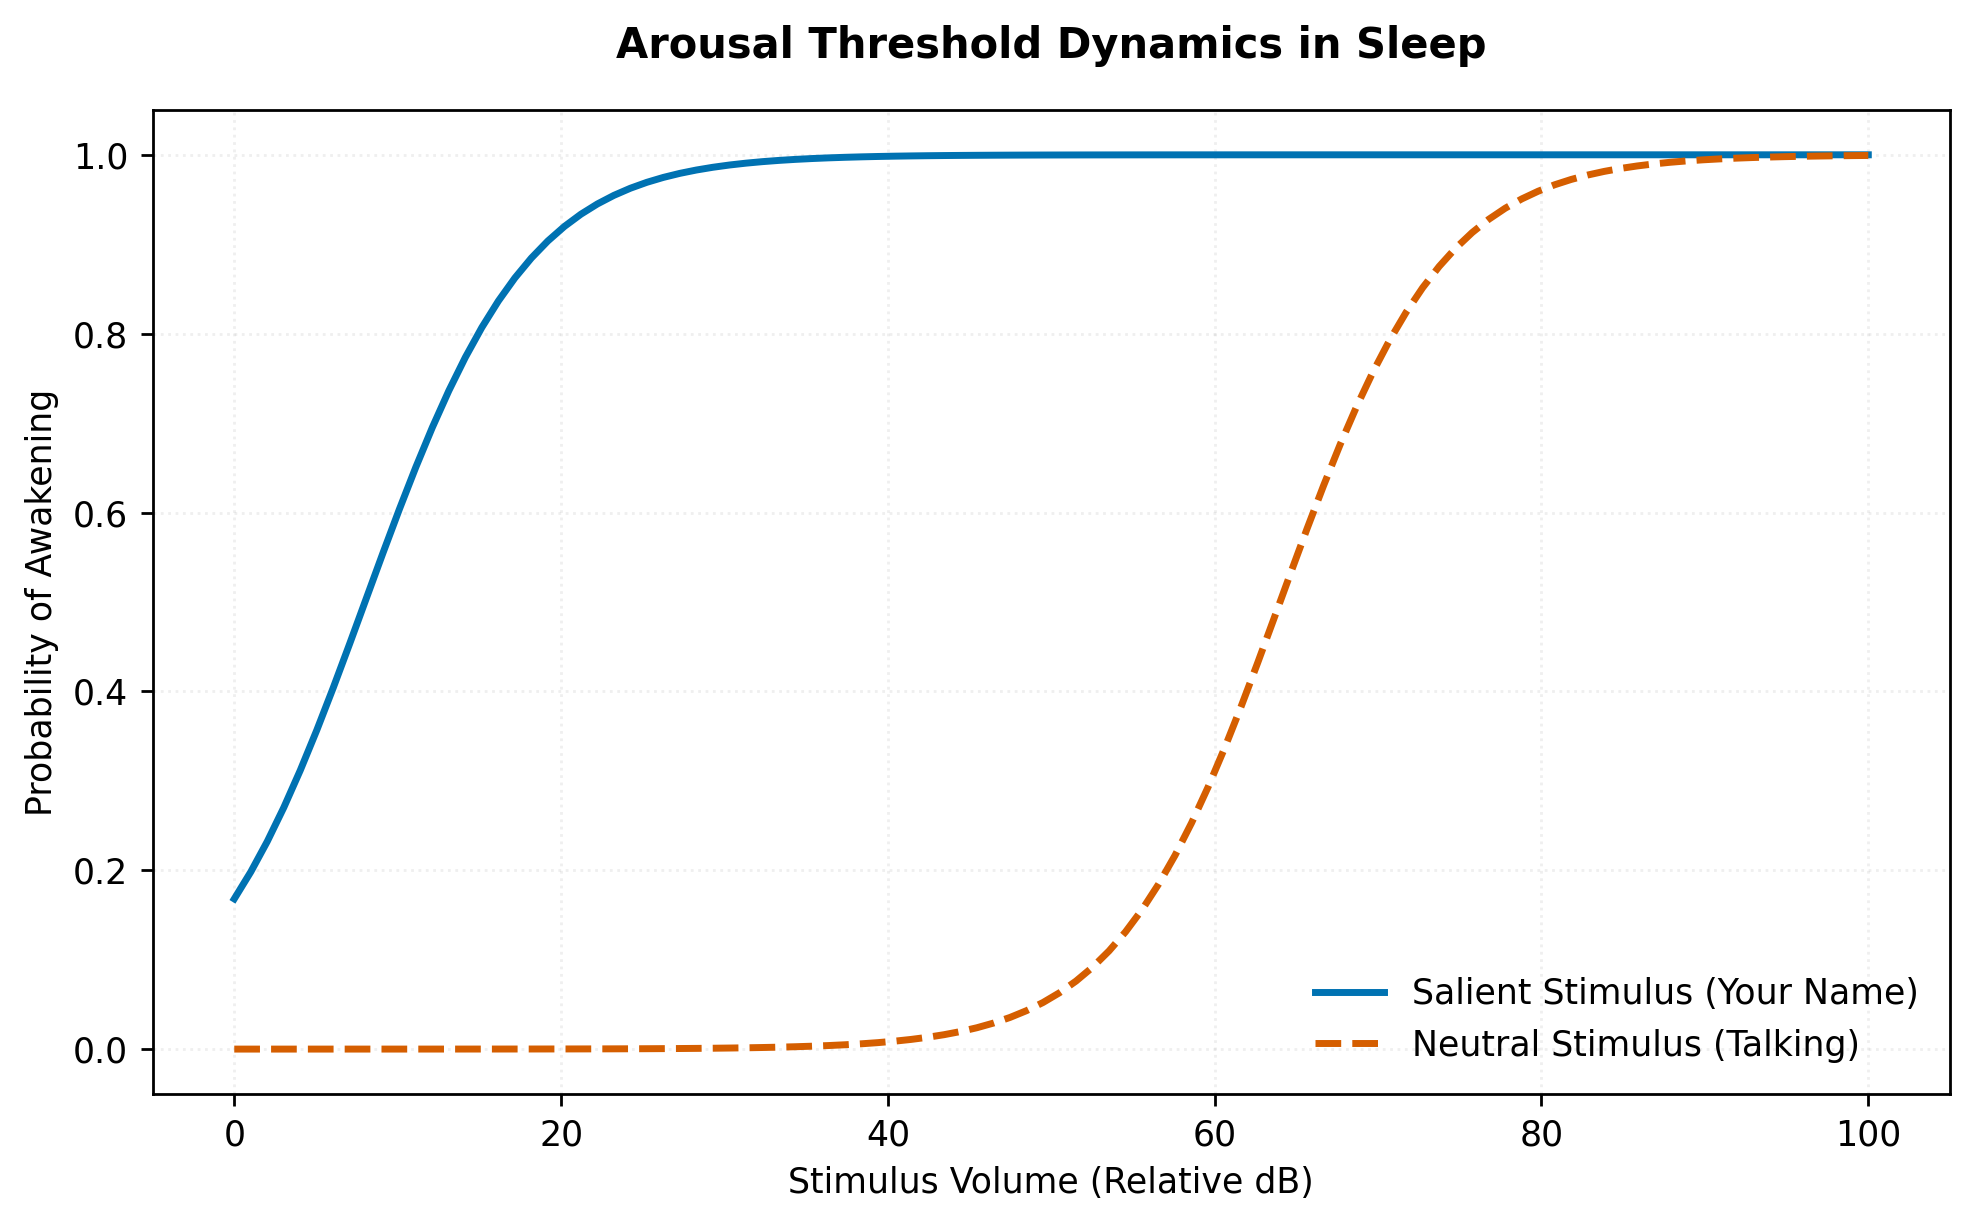

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONTROL KNOBS ---
SLEEP_DEPTH = 0.8        # Normalized depth (0.0: light sleep, 1.0: deep sleep)
NAME_SALIENCE = 0.9      # Sensitivity to one's own name (0.0 to 1.0)
NEUTRAL_SALIENCE = 0.2   # Sensitivity to random background talking (0.0 to 1.0)
VOLUME_LEVELS = np.linspace(0, 100, 100)  # Decibel (dB) range
# ---------------------


def calculate_arousal_probability(volume, salience, sleep_depth):
    """
    Calculate the probability of awakening using a modified sigmoid function.

    This function adjusts the baseline logistic curve using stimulus salience
    and the current sleep depth to model auditory arousal thresholds accurately.

    Args:
        volume (numpy.ndarray): The array of stimulus volume levels
                                measured in relative decibels (dB).
        salience (float): The subjective importance of the stimulus,
                          ranging from 0.0 to 1.0.
        sleep_depth (float): The normalized depth of sleep,
                             ranging from 0.0 (awake) to 1.0 (deep).

    Returns:
        numpy.ndarray: The computed arousal probabilities corresponding
                       to each volume level.
    """
    threshold = (1.0 - salience) * 100.0 * sleep_depth
    return 1.0 / (1.0 + np.exp(-0.2 * (volume - threshold)))


def main():
    """Execute the primary plotting sequence for sleep arousal dynamics."""
    p_name = calculate_arousal_probability(
        VOLUME_LEVELS, NAME_SALIENCE, SLEEP_DEPTH
    )
    p_neutral = calculate_arousal_probability(
        VOLUME_LEVELS, NEUTRAL_SALIENCE, SLEEP_DEPTH
    )

    plt.rcParams.update({
        'font.sans-serif': ['IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif'],
        'font.weight': 'normal',
        'axes.titleweight': 'semibold',
        'figure.dpi': 250
    })

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        VOLUME_LEVELS,
        p_name,
        label="Salient Stimulus (Your Name)",
        color='#0072B2',
        linewidth=2
    )
    ax.plot(
        VOLUME_LEVELS,
        p_neutral,
        label="Neutral Stimulus (Talking)",
        color='#D55E00',
        linestyle='--',
        linewidth=2
    )

    ax.set_xlabel("Stimulus Volume (Relative dB)", fontweight='normal')
    ax.set_ylabel("Probability of Awakening", fontweight='normal')
    ax.set_title("Arousal Threshold Dynamics in Sleep", pad=15)
    ax.grid(alpha=0.2, linestyle=':')
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

Using Python 3.12.13 environment at: /usr
Checked 1 package in 203ms


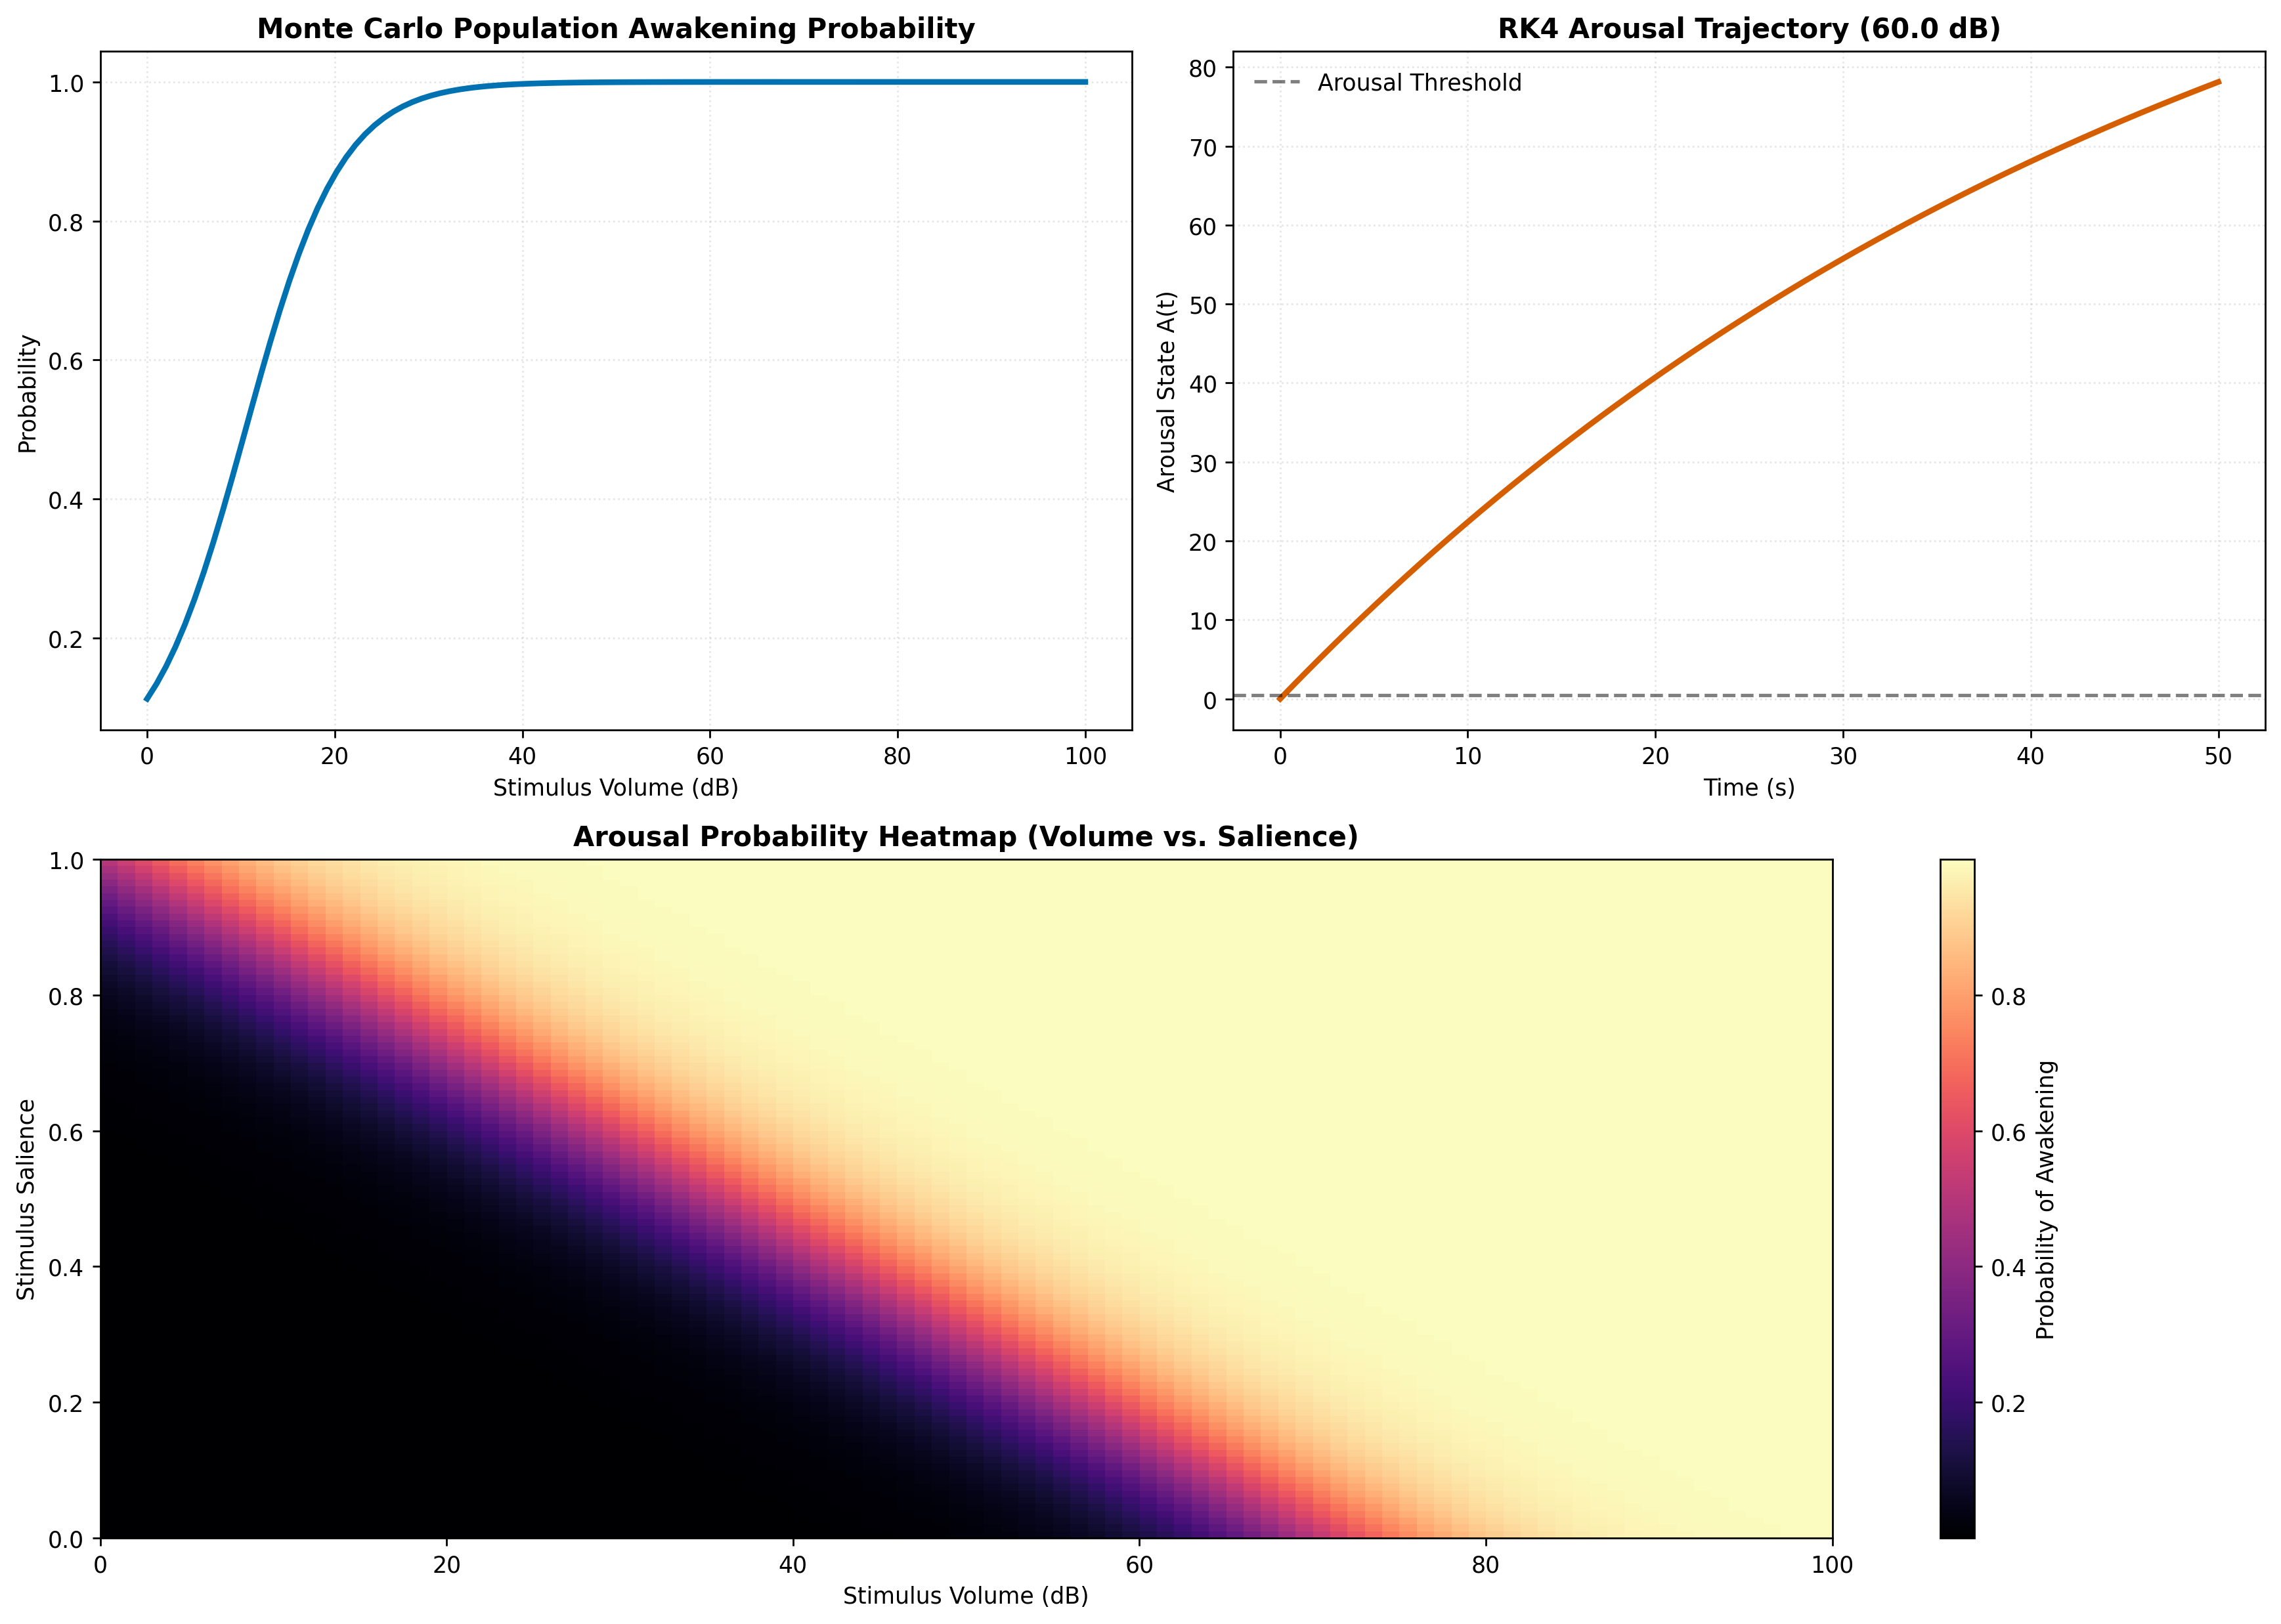

In [3]:
!uv pip install cupy-cuda12x  # Ensure the CuPy version matches the Colab CUDA environment
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# --- CONTROL KNOBS ---
NUM_SIMULATIONS = 100_000   # Number of Monte Carlo trajectories
TIME_STEPS = 500            # Total duration steps for RK4 integration
DT = 0.1                    # Time step size (seconds)
SLEEP_DEPTH_MU = 0.7        # Mean sleep depth for population distribution
SALIENCE_VAL = 0.85         # Cognitive importance of the stimulus
VOL_SENSITIVITY = 0.2       # Logistic growth rate (k)
ACCUMULATION_RATE = 0.05    # Rate at which arousal builds (gamma)
DECAY_RATE = 0.02           # Rate at which arousal dissipates (lambda)
# ---------------------

def calculate_mc_cupy(volumes, salience, sleep_depth_mu, n_sims):
    """
    Perform a GPU-accelerated Monte Carlo simulation of awakening probability.

    This function simulates a population of sleepers with normally distributed
    sensitivities to determine the aggregate probability of arousal.

    Args:
        volumes (cp.ndarray): Stimulus intensity levels.
        salience (float): Subjective importance of the sound.
        sleep_depth_mu (float): Average population sleep depth.
        n_sims (int): Number of stochastic samples.

    Returns:
        cp.ndarray: The mean probability across the population.
    """
    # Introduce stochasticity in sleep depth across the population
    depth_samples = cp.random.normal(sleep_depth_mu, 0.1, n_sims)
    depth_samples = cp.clip(depth_samples, 0.1, 1.0)

    # Broadcast and compute sigmoid: 1 / (1 + exp(-k * (V - threshold)))
    # threshold = (1 - salience) * 100 * depth
    thresholds = (1.0 - salience) * 100.0 * depth_samples

    # Reshape for broadcasting (n_volumes, n_sims)
    v_mesh, t_mesh = cp.meshgrid(volumes, thresholds, indexing='ij')
    probabilities = 1.0 / (1.0 + cp.exp(-VOL_SENSITIVITY * (v_mesh - t_mesh)))

    return cp.mean(probabilities, axis=1)

def arousal_derivative(a, volume, threshold):
    """
    Define the first-order differential equation for arousal state.

    The arousal state increases with stimulus excess and decays naturally.
    da/dt = gamma * max(0, volume - threshold) - lambda * a
    """
    drive = cp.maximum(0, volume - threshold)
    return ACCUMULATION_RATE * drive - DECAY_RATE * a

def rk4_step(a, volume, threshold, dt):
    """
    Perform a single iteration using the Runge-Kutta 4th Order method.
    """
    k1 = arousal_derivative(a, volume, threshold)
    k2 = arousal_derivative(a + 0.5 * dt * k1, volume, threshold)
    k3 = arousal_derivative(a + 0.5 * dt * k2, volume, threshold)
    k4 = arousal_derivative(a + dt * k3, volume, threshold)
    return a + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

def main():
    """Execute simulation and generate Nature-style diagnostic plots."""
    vol_range = cp.linspace(0, 100, 100)
    salience_range = cp.linspace(0, 1, 100)

    # 1. Monte Carlo GPU Simulation
    p_mc = calculate_mc_cupy(vol_range, SALIENCE_VAL, SLEEP_DEPTH_MU, NUM_SIMULATIONS)

    # 2. RK4 Time-Domain Simulation
    # Simulate arousal over time for a constant 60dB stimulus
    constant_vol = 60.0
    threshold_fixed = (1.0 - SALIENCE_VAL) * 100.0 * SLEEP_DEPTH_MU
    arousal_history = cp.zeros(TIME_STEPS)
    a_current = cp.array([0.0])

    for t in range(TIME_STEPS):
        arousal_history[t] = a_current
        a_current = rk4_step(a_current, constant_vol, threshold_fixed, DT)

    # 3. Heatmap Generation (Probability vs Volume vs Salience)
    v_grid, s_grid = cp.meshgrid(vol_range, salience_range)
    t_grid = (1.0 - s_grid) * 100.0 * SLEEP_DEPTH_MU
    z_heatmap = 1.0 / (1.0 + cp.exp(-VOL_SENSITIVITY * (v_grid - t_grid)))

    # Move data to CPU for plotting
    vol_np = cp.asnumpy(vol_range)
    p_mc_np = cp.asnumpy(p_mc)
    arousal_np = cp.asnumpy(arousal_history)
    z_np = cp.asnumpy(z_heatmap)
    time_axis = np.linspace(0, TIME_STEPS * DT, TIME_STEPS)

    # Plotting Configuration
    plt.rcParams.update({
        'font.sans-serif': ['IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif'],
        'font.weight': 'normal',
        'axes.titleweight': 'semibold',
        'figure.dpi': 250
    })

    fig = plt.figure(figsize=(14, 10))

    # Subplot 1: Monte Carlo Results
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(vol_np, p_mc_np, color='#0072B2', linewidth=2.5)
    ax1.set_title("Monte Carlo Population Awakening Probability")
    ax1.set_xlabel("Stimulus Volume (dB)")
    ax1.set_ylabel("Probability")
    ax1.grid(alpha=0.3, linestyle=':')

    # Subplot 2: RK4 Temporal Dynamics
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(time_axis, arousal_np, color='#D55E00', linewidth=2.5)
    ax2.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Arousal Threshold')
    ax2.set_title(f"RK4 Arousal Trajectory ({constant_vol} dB)")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Arousal State A(t)")
    ax2.legend(frameon=False)
    ax2.grid(alpha=0.3, linestyle=':')

    # Subplot 3: Heatmap Analysis
    ax3 = fig.add_subplot(2, 1, 2)
    im = ax3.imshow(z_np, extent=[0, 100, 0, 1], origin='lower', aspect='auto', cmap='magma')
    ax3.set_title("Arousal Probability Heatmap (Volume vs. Salience)")
    ax3.set_xlabel("Stimulus Volume (dB)")
    ax3.set_ylabel("Stimulus Salience")
    fig.colorbar(im, ax=ax3, label='Probability of Awakening')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()